# 02 — XBRL Company Facts (Milestone M1)

**DSML stage:** data acquisition & understanding. **Scope:** Nvidia only.

**The project's cardinal rule (from the feasibility studies): no LLM ever parses financial numbers.**
All quantitative facts (revenue, capex, R&D) come deterministically from the SEC **XBRL Company Facts API**
(`data.sec.gov/api/xbrl/companyfacts/CIK##########.json`). These become `Metric` nodes + `REPORTS_METRIC`
edges in the graph (notebook 06).

This notebook: fetch raw companyfacts JSON → parse to a tidy long table → explore taxonomy quirks →
persist a curated metric table for the graph loader.

In [1]:
import json
import os
import urllib.request
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
load_dotenv(PROJECT_ROOT / ".env")
SEC_USER_AGENT = os.getenv("SEC_USER_AGENT", "Amit Badave amit11badave.ab@gmail.com")

NVDA_CIK = 1045810
RAW_XBRL = PROJECT_ROOT / "data" / "raw" / "xbrl"
PROCESSED_XBRL = PROJECT_ROOT / "data" / "processed" / "xbrl"
RAW_XBRL.mkdir(parents=True, exist_ok=True)
PROCESSED_XBRL.mkdir(parents=True, exist_ok=True)

## 1. Fetch and persist the raw companyfacts JSON (immutable input)

In [2]:
raw_path = RAW_XBRL / f"CIK{NVDA_CIK:010d}_companyfacts.json"
if not raw_path.exists():
    req = urllib.request.Request(
        f"https://data.sec.gov/api/xbrl/companyfacts/CIK{NVDA_CIK:010d}.json",
        headers={"User-Agent": SEC_USER_AGENT},
    )
    raw_path.write_bytes(urllib.request.urlopen(req).read())

facts_json = json.loads(raw_path.read_text())
print(f"Entity: {facts_json['entityName']}")
print(f"Taxonomies: {list(facts_json['facts'].keys())}")
print(f"us-gaap concepts: {len(facts_json['facts']['us-gaap'])}")

Entity: NVIDIA CORP
Taxonomies: ['dei', 'invest', 'us-gaap', 'srt', 'ecd', 'ffd']
us-gaap concepts: 626


## 2. Parse to a tidy long table

One row per *(concept, unit, period, filing)* fact. Columns follow the SEC API's own vocabulary:
`fy`/`fp` are the **filing's** fiscal year/period, `start`/`end` delimit the fact's own period,
`accn` ties every number back to the exact filing (provenance!), `frame` marks the canonical fact for a period.

In [3]:
rows = []
for taxonomy, concepts in facts_json["facts"].items():
    for concept, payload in concepts.items():
        for unit, facts in payload["units"].items():
            for fact in facts:
                rows.append({
                    "taxonomy": taxonomy,
                    "concept": concept,
                    "label": payload.get("label"),
                    "unit": unit,
                    "start": fact.get("start"),
                    "end": fact.get("end"),
                    "val": fact.get("val"),
                    "accn": fact.get("accn"),
                    "fy": fact.get("fy"),
                    "fp": fact.get("fp"),
                    "form": fact.get("form"),
                    "filed": fact.get("filed"),
                    "frame": fact.get("frame"),
                })

facts_df = pd.DataFrame(rows)
print(f"{len(facts_df):,} facts across {facts_df['concept'].nunique():,} concepts")
facts_df.head(3)

26,903 facts across 642 concepts


,taxonomy,concept,label,unit,start,end,val,accn,fy,fp,form,filed,frame
0,dei,EntityCommonStockSharesOutstanding,"Entity Common Stock, Shares Outstanding",shares,None,2009-08-17,547800000.0,0001045810-09-000024,2009.0,Q2,10-Q,2009-08-20,CY2009Q3I
1,dei,EntityCommonStockSharesOutstanding,"Entity Common Stock, Shares Outstanding",shares,None,2009-11-17,554900000.0,0001045810-09-000036,2009.0,Q3,10-Q,2009-11-19,CY2009Q4I
2,dei,EntityCommonStockSharesOutstanding,"Entity Common Stock, Shares Outstanding",shares,None,2010-03-10,566500000.0,0001045810-10-000006,2010.0,FY,10-K,2010-03-18,CY2010Q1I


## 3. The metrics that matter for this project

The graph's `Metric` nodes track the AI-supercycle storyline: **revenue** (demand), **capex** (infrastructure
build-out), **R&D** (design investment), **purchase obligations** (supply commitments). US-GAAP concept names
drift across years — a known taxonomy quirk we must handle.

In [4]:
KEY_CONCEPTS = {
    "revenue": ["Revenues", "RevenueFromContractWithCustomerExcludingAssessedTax"],
    "capex": ["PaymentsToAcquirePropertyPlantAndEquipment"],
    "rnd": ["ResearchAndDevelopmentExpense"],
    "net_income": ["NetIncomeLoss"],
}

def annual_series(df: pd.DataFrame, concepts: list[str]) -> pd.DataFrame:
    """Full-fiscal-year facts from 10-K filings, one canonical row per period end."""
    sel = df[
        df["concept"].isin(concepts)
        & (df["form"] == "10-K")
        & (df["fp"] == "FY")
        & df["start"].notna()
    ].copy()
    sel["days"] = (pd.to_datetime(sel["end"]) - pd.to_datetime(sel["start"])).dt.days
    sel = sel[sel["days"] > 300]  # keep full-year periods only (10-Ks restate quarters too)
    # facts are re-reported as comparatives in later filings — keep the earliest report per period
    sel = sel.sort_values("filed").groupby("end", as_index=False).first()
    return sel[["concept", "start", "end", "val", "accn", "fy", "form", "filed"]].sort_values("end")

revenue = annual_series(facts_df, KEY_CONCEPTS["revenue"])
revenue["val_bn"] = (revenue["val"] / 1e9).round(3)
revenue

,concept,start,end,val,accn,fy,form,filed,val_bn
0,Revenues,2007-01-29,2008-01-27,4.097860e+09,0001045810-10-000006,2010.0,10-K,2010-03-18,4.098
1,Revenues,2008-01-28,2009-01-25,3.424859e+09,0001045810-10-000006,2010.0,10-K,2010-03-18,3.425
2,Revenues,2009-01-26,2010-01-31,3.326445e+09,0001045810-10-000006,2010.0,10-K,2010-03-18,3.326
3,Revenues,2010-02-01,2011-01-30,3.543309e+09,0001045810-11-000015,2010.0,10-K,2011-03-16,3.543
4,Revenues,2011-01-31,2012-01-29,3.997930e+09,0001045810-12-000013,2011.0,10-K,2012-03-13,3.998
5,Revenues,2012-01-30,2013-01-27,4.280159e+09,0001045810-13-000008,2012.0,10-K,2013-03-12,4.280
6,Revenues,2013-01-28,2014-01-26,4.130162e+09,0001045810-14-000030,2013.0,10-K,2014-03-13,4.130
7,Revenues,2014-01-27,2015-01-25,4.681507e+09,0001045810-15-000036,2015.0,10-K,2015-03-12,4.682
8,Revenues,2015-01-26,2016-01-31,5.010000e+09,0001045810-16-000205,2016.0,10-K,2016-03-17,5.010
9,Revenues,2016-02-01,2017-01-29,6.910000e+09,0001045810-17-000027,2017.0,10-K,2017-03-01,6.910


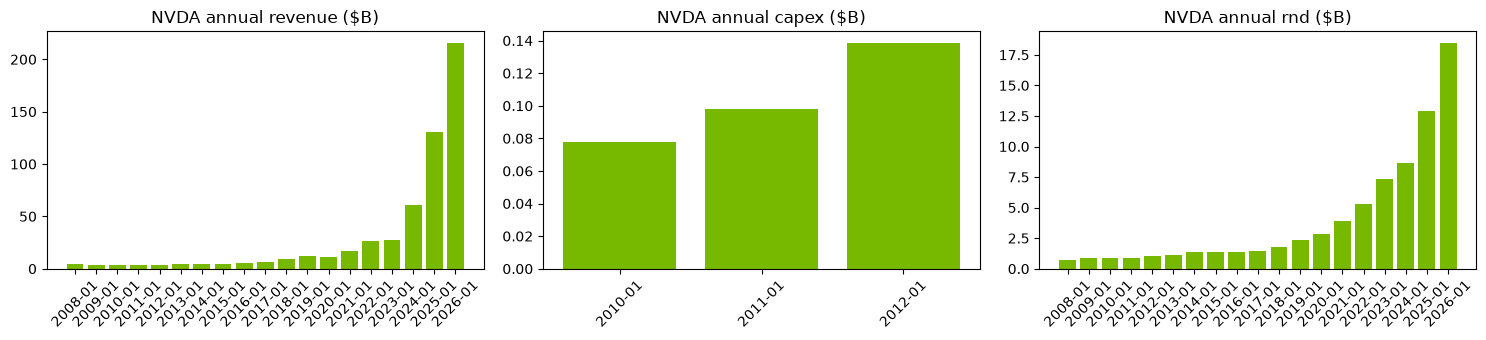

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, (name, concepts) in zip(axes, [(k, KEY_CONCEPTS[k]) for k in ("revenue", "capex", "rnd")]):
    series = annual_series(facts_df, concepts)
    ax.bar(series["end"].str[:7], series["val"] / 1e9, color="#76b900")
    ax.set_title(f"NVDA annual {name} ($B)")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 4. Taxonomy quirks (data dictionary)

Findings that downstream notebooks must respect:

1. **Fiscal-year offset** — Nvidia's FY ends late January: *FY2024 = period ending 2024-01-28*, which is
   mostly calendar 2023. The graph must store `period_start`/`period_end` dates, never bare "FY" labels.
2. **Concept drift** — older filings report revenue as `Revenues`; newer ones use
   `RevenueFromContractWithCustomerExcludingAssessedTax` (ASC 606). Loaders take a concept *list* per metric.
3. **Comparative re-reporting** — each 10-K restates 2 prior years, so the same fact appears in ≥3 filings.
   We deduplicate by `(concept, end)` keeping the earliest `filed` (first disclosure = the citable event).
4. **`frame` field** — the SEC marks one canonical fact per period (e.g. `CY2023`); useful as a cross-check.
5. **Units** — almost all `USD`, but shares/pure units exist; `Metric` nodes carry an explicit `unit` property.

**Curated output** (`data/processed/xbrl/NVDA_key_metrics.parquet`): one row per metric-period with
`metric`, `concept`, `start`, `end`, `val`, `unit`, `accn` (provenance), `filed`.

In [6]:
curated = []
for metric, concepts in KEY_CONCEPTS.items():
    series = annual_series(facts_df, concepts)
    series.insert(0, "metric", metric)
    series["unit"] = "USD"
    series["ticker"] = "NVDA"
    series["cik"] = NVDA_CIK
    curated.append(series)
curated_df = pd.concat(curated, ignore_index=True)

curated_path = PROCESSED_XBRL / "NVDA_key_metrics.parquet"
curated_df.to_parquet(curated_path, index=False)
full_path = PROCESSED_XBRL / "NVDA_all_facts.parquet"
facts_df.to_parquet(full_path, index=False)
print(f"curated: {len(curated_df)} rows → {curated_path.name}")
print(f"full:    {len(facts_df):,} rows → {full_path.name}")
curated_df[curated_df["metric"] == "capex"][["metric", "end", "val", "accn"]].tail(3)

curated: 60 rows → NVDA_key_metrics.parquet
full:    26,903 rows → NVDA_all_facts.parquet


,metric,end,val,accn
19,capex,2010-01-31,77601000.0,0001045810-12-000013
20,capex,2011-01-30,97890000.0,0001045810-12-000013
21,capex,2012-01-29,138735000.0,0001045810-12-000013


In [7]:
# --- M1 assertion cell ---
# Ground truth: NVDA FY2024 (period ended 2024-01-28) revenue was $60.922B — immutable history.
fy24 = curated_df[(curated_df["metric"] == "revenue") & (curated_df["end"] == "2024-01-28")]
assert len(fy24) == 1, "Expected exactly one canonical FY2024 revenue fact"
assert abs(fy24.iloc[0]["val"] - 60_922_000_000) < 1e6, f"FY2024 revenue mismatch: {fy24.iloc[0]['val']}"
assert curated_df["metric"].nunique() == 4 and curated_df["accn"].notna().all()
assert raw_path.exists() and curated_path.exists()
print("M1 (XBRL) OK — raw JSON + curated parquet persisted; FY2024 revenue verified at $60.922B")

M1 (XBRL) OK — raw JSON + curated parquet persisted; FY2024 revenue verified at $60.922B
